# Assignment 2: Build Regression Models

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80)

## Conceptual Question 3

For the model Salary = 50 + 20GPA + 0.07IQ + 35Level + 0.01(GPA x IQ) - 10(GPA x Level), the college-versus-high-school difference at fixed GPA and IQ is 35 - 10GPA.  College graduates earn more when GPA is below 3.5, the two groups are equal at GPA 3.5, and high school graduates earn more when GPA is above 3.5.  Therefore, statement iii is the correct interpretation.  A college graduate with IQ 110 and GPA 4.0 has a predicted salary of 137.1 thousand dollars.  The small numerical coefficient on GPA x IQ does not by itself prove a weak interaction because statistical evidence depends on the coefficient relative to its standard error, not only on the raw coefficient size (James et al., 2023).

In [2]:
gpa = 4.0
iq = 110
level_college = 1
salary = 50 + 20*gpa + 0.07*iq + 35*level_college + 0.01*gpa*iq - 10*gpa*level_college
crossover_gpa = 35 / 10
pd.DataFrame({
    "quantity": ["predicted_salary_thousands", "college_high_school_crossover_gpa"],
    "value": [salary, crossover_gpa],
})

,quantity,value
0,predicted_salary_thousands,137.1
1,college_high_school_crossover_gpa,3.5


## Applied Question 10: Carseats Regression

The Carseats exercise is useful because it forces the model to handle both numeric and qualitative predictors.  Price is numeric, while Urban and US enter as indicator variables.

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.39e-23
Time:                        12:20:40   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.0435      0.651     20.036   

,part,answer
0,(a) Full model,Fit Sales ~ Price + Urban + US.
1,(b) Coefficient interpretation,Price is negative; US is positive; Urban is no...
2,(c) Smaller fitted equation,Sales = 13.031 - 0.0545(Price) + 1.200(US.Yes).
3,(d) Rejected H0 terms,Reject Price and US at alpha=.05; do not rejec...
4,(e) Smaller model,Fit Sales ~ Price + US.
5,(f) Fit comparison,"Full R2=0.239, adj R2=0.234, AIC=1863.3; small..."
6,(g) 95 percent confidence intervals,Shown in the confidence interval table below.
7,(h) Outliers and leverage,"Checked leverage, externally studentized resid..."


,lower_95,upper_95
Intercept,11.79032,14.271265
US[T.Yes],0.69152,1.707766
Price,-0.06476,-0.044195


,term,vif
0,Intercept,26.115860
1,US[T.Yes],1.003359
2,Price,1.003359


,assumption_or_check,evidence
0,Linearity / constant variance,Breusch-Pagan p=0.085; residual plot inspected
1,Independence of errors,Durbin-Watson=1.912
2,Residual distribution,Jarque-Bera p=0.688; Q-Q plot inspected
3,Collinearity,Maximum non-intercept VIF=1.003
4,Outliers,Max absolute externally studentized residual=2...
5,Influential observations,Max leverage=0.043; max Cook's D=0.026
6,Model parsimony,Full R2=0.239; smaller R2=0.239


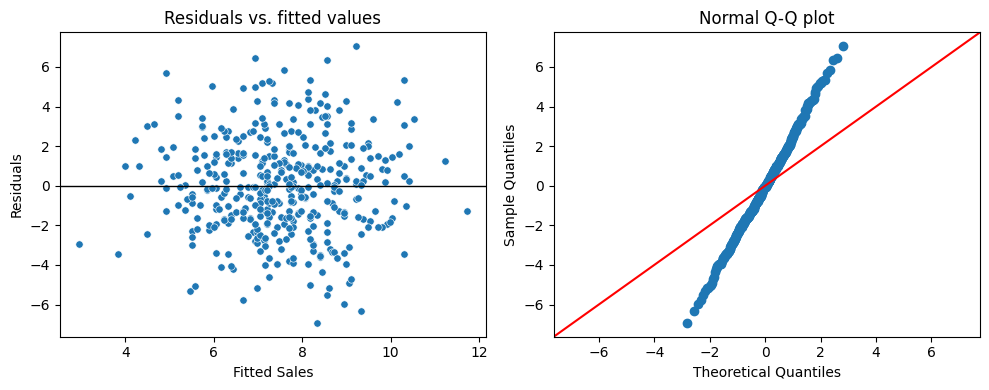

In [3]:
from ISLP import load_data
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

carseats = load_data("Carseats")
model_full = smf.ols("Sales ~ Price + Urban + US", data=carseats).fit()
model_small = smf.ols("Sales ~ Price + US", data=carseats).fit()

print(model_full.summary())
print("\nSmaller model")
print(model_small.summary())

print("\nApplied Question 10 visible checklist")
ci = model_small.conf_int()
ci.columns = ["lower_95", "upper_95"]
price_coef = model_small.params["Price"]
us_coef = model_small.params["US[T.Yes]"]
display(pd.DataFrame({
    "part": [
        "(a) Full model",
        "(b) Coefficient interpretation",
        "(c) Smaller fitted equation",
        "(d) Rejected H0 terms",
        "(e) Smaller model",
        "(f) Fit comparison",
        "(g) 95 percent confidence intervals",
        "(h) Outliers and leverage",
    ],
    "answer": [
        "Fit Sales ~ Price + Urban + US.",
        "Price is negative; US is positive; Urban is not clearly different from zero.",
        f"Sales = {model_small.params['Intercept']:.3f} {'-' if price_coef < 0 else '+'} {abs(price_coef):.4f}(Price) {'-' if us_coef < 0 else '+'} {abs(us_coef):.3f}(US.Yes).",
        "Reject Price and US at alpha=.05; do not reject Urban.",
        "Fit Sales ~ Price + US.",
        f"Full R2={model_full.rsquared:.3f}, adj R2={model_full.rsquared_adj:.3f}, AIC={model_full.aic:.1f}; smaller R2={model_small.rsquared:.3f}, adj R2={model_small.rsquared_adj:.3f}, AIC={model_small.aic:.1f}.",
        "Shown in the confidence interval table below.",
        "Checked leverage, externally studentized residuals, and Cook's distance.",
    ],
}))
display(ci)

vif = pd.DataFrame({
    "term": model_small.model.exog_names,
    "vif": [variance_inflation_factor(model_small.model.exog, i) for i in range(model_small.model.exog.shape[1])],
})
display(vif)

influence = model_small.get_influence()
studentized = influence.resid_studentized_external
cooks = influence.cooks_distance[0]
bp_f_pvalue = het_breuschpagan(model_small.resid, model_small.model.exog)[3]
diag = pd.DataFrame({
    "assumption_or_check": [
        "Linearity / constant variance",
        "Independence of errors",
        "Residual distribution",
        "Collinearity",
        "Outliers",
        "Influential observations",
        "Model parsimony",
    ],
    "evidence": [
        f"Breusch-Pagan p={bp_f_pvalue:.3f}; residual plot inspected",
        f"Durbin-Watson={durbin_watson(model_small.resid):.3f}",
        f"Jarque-Bera p={stats.jarque_bera(model_small.resid).pvalue:.3f}; Q-Q plot inspected",
        f"Maximum non-intercept VIF={vif.loc[vif.term != 'Intercept', 'vif'].max():.3f}",
        f"Max absolute externally studentized residual={np.max(np.abs(studentized)):.3f}",
        f"Max leverage={influence.hat_matrix_diag.max():.3f}; max Cook's D={cooks.max():.3f}",
        f"Full R2={model_full.rsquared:.3f}; smaller R2={model_small.rsquared:.3f}",
    ],
})
display(diag)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(x=model_small.fittedvalues, y=model_small.resid, ax=axes[0], s=28)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuals vs. fitted values")
axes[0].set_xlabel("Fitted Sales")
axes[0].set_ylabel("Residuals")
sm.qqplot(model_small.resid, line="45", ax=axes[1])
axes[1].set_title("Normal Q-Q plot")
plt.tight_layout()

The full model shows that Price and US are statistically meaningful, while Urban is not.  The smaller model keeps Price and US because those predictors have evidence of association with Sales, and removing Urban leaves R2 essentially unchanged.  The fitted smaller equation is Sales = 13.031 - 0.0545(Price) + 1.200(US).  The negative Price coefficient means expected sales decrease by about 0.0545 thousand units for each one-dollar increase in price, holding the US indicator constant.  The positive US coefficient means stores in the United States are expected to sell about 1.2 thousand more units than non-US stores at the same price.  The confidence intervals exclude zero for Price and US, which supports rejecting the null hypotheses for those predictors.  The diagnostics support a cautious interpretation: Durbin-Watson is close to 2, VIF values are low, the Jarque-Bera result does not show strong residual non-normality, and the visual residual checks do not show a pattern severe enough to invalidate the model.  The low R2 still matters because the model explains only part of sales variation, so it is better for directional interpretation than for complete forecasting.

## Kaggle Regression with Abalone

Two Kaggle submissions were made for the Abalone regression competition: a ridge regression baseline and a random forest regression model.  The notebook keeps local validation separate from Kaggle scoring so the interpretation is not based only on the public leaderboard.  Ridge is used as a regularized linear benchmark, while random forest is used as a nonlinear ensemble benchmark that can capture interactions among abalone measurements.  The abalone task is substantively appropriate because age is traditionally inferred from shell rings, while the competition asks whether easier physical measurements can predict that outcome (Nash et al., 1994).

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

abalone = pd.read_csv(KAGGLE / "playground-series-s4e4" / "train.csv")
X = abalone.drop(columns=["Rings"])
y = abalone["Rings"]
cat = ["Sex"]
num = [c for c in X.columns if c not in cat + ["id"]]
pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ("num", StandardScaler(), num),
], remainder="drop")
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=.2, random_state=RANDOM_STATE)
models = {
    "Ridge": Pipeline([("pre", pre), ("model", Ridge(alpha=10.0))]),
    "Random forest": Pipeline([("pre", pre), ("model", RandomForestRegressor(n_estimators=120, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1))]),
}
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = np.maximum(model.predict(X_valid), 1)
    rows.append({"model": name, "validation_rmsle": np.sqrt(mean_squared_log_error(y_valid, pred))})
validation_results = pd.DataFrame(rows).sort_values("validation_rmsle")
display(validation_results)

,model,validation_rmsle
1,Random forest,0.153956
0,Ridge,0.165662


,feature,vif
1,Diameter,959.988285
0,Length,895.831782
3,Whole weight,271.722902
2,Height,99.990913
4,Whole weight.1,80.573934
5,Whole weight.2,75.887621
6,Shell weight,71.367188


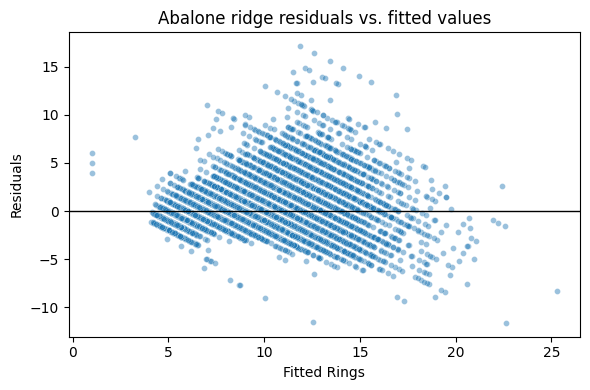

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

abalone_numeric = X_train[num].copy()
abalone_vif = pd.DataFrame({
    "feature": num,
    "vif": [variance_inflation_factor(abalone_numeric.values, i) for i in range(abalone_numeric.shape[1])],
}).sort_values("vif", ascending=False)
display(abalone_vif)

ridge_pred = np.maximum(models["Ridge"].predict(X_valid), 1)
ridge_resid = y_valid - ridge_pred
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x=ridge_pred, y=ridge_resid, s=18, alpha=.45, ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Abalone ridge residuals vs. fitted values")
ax.set_xlabel("Fitted Rings")
ax.set_ylabel("Residuals")
plt.tight_layout()

In [6]:
import re

status_path = SUBMISSIONS / "kaggle_submission_status_playground-series-s4e4.txt"
for encoding in ("utf-16", "utf-8"):
    try:
        text = status_path.read_text(encoding=encoding)
        break
    except UnicodeError:
        continue

records = []
current = {}
for line in text.splitlines():
    if not line.strip():
        continue
    if "ref" in line and "fileName" in line:
        continue
    if re.match(r"^\d+", line.strip()):
        if current:
            records.append(current)
        parts = re.split(r"\s{2,}", line.strip())
        if len(parts) >= 7:
            current = {
                "ref": parts[0],
                "fileName": parts[1],
                "date": parts[2],
                "description": parts[3],
                "status": parts[4],
                "publicScore": parts[5],
                "privateScore": parts[6],
            }
    elif current and "A2_" in current.get("fileName", ""):
        current["description"] = (current.get("description", "") + " " + line.strip()).strip()
if current:
    records.append(current)

a2_records = pd.DataFrame([row for row in records if "A2_" in row.get("fileName", "")])
display(a2_records)
display(pd.DataFrame({
    "submission_file": [
        "A2_ridge_playground_series_s4e4.csv",
        "A2_random_forest_playground_series_s4e4.csv",
    ],
    "exists_locally": [
        (SUBMISSIONS / "A2_ridge_playground_series_s4e4.csv").exists(),
        (SUBMISSIONS / "A2_random_forest_playground_series_s4e4.csv").exists(),
    ],
}))
display(pd.DataFrame({
    "evidence": ["Public GitHub repository", "Notebook path in repository"],
    "value": [
        "https://github.com/maldo81/dds-8555-predictive-analysis",
        "Week 2/Assignment 2/MaldonadoJDDS8555-2.ipynb",
    ],
}))

,ref,fileName,date,description,status,publicScore,privateScore
0,52966788,A2_random_forest_playground_series_s4e4.csv,2026-05-23 21:27:11.893000,DDS-8555 A2 random forest regression,SubmissionStatus.COMPLETE,0.14927,0.14943
1,52966787,A2_ridge_playground_series_s4e4.csv,2026-05-23 21:27:09.197000,DDS-8555 A2 ridge regression baseline,SubmissionStatus.COMPLETE,0.16442,0.16372


,submission_file,exists_locally
0,A2_ridge_playground_series_s4e4.csv,True
1,A2_random_forest_playground_series_s4e4.csv,True


,evidence,value
0,Public GitHub repository,https://github.com/maldo81/dds-8555-predictive...
1,Notebook path in repository,Week 2/Assignment 2/MaldonadoJDDS8555-2.ipynb


## Interpretation

The ridge model provides a stable linear benchmark, while the random forest can capture interactions and nonlinear structure without manually specifying every term.  The validation results and Kaggle scores both favored the random forest submission, which strengthens the case that the abalone measurements contain nonlinear signal.  The Abalone VIF table shows why a regularized baseline is sensible: shell size and weight measurements carry overlapping information, so shrinkage helps stabilize the linear benchmark.  Regression assumptions are most directly relevant to the linear models: the Carseats analysis checks linearity and constant variance through residual structure, independence through Durbin-Watson, collinearity through VIF, and residual shape through Jarque-Bera and Q-Q diagnostics.  The random forest relaxes the linearity and normal-residual assumptions, but it still requires held-out validation because flexibility can hide overfitting.  The practical finding is therefore split: the simpler regression is useful for explaining directional effects, while the random forest is the better submission model for this prediction task.

## References

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*.  Springer. https://doi.org/10.1007/978-3-031-38747-0

Nash, W.  J., Sellers, T.  L., Talbot, S.  R., Cawthorn, A.  J., & Ford, W.  B. (1994). *The population biology of abalone (Haliotis species) in Tasmania.  I.  Blacklip abalone (H. rubra) from the north coast and islands of Bass Strait* (Technical Report No.  48).  Sea Fisheries Division.

Snee, R.  D. (1977).  Validation of regression models: Methods and examples. *Technometrics, 19*(4), 415-428. https://doi.org/10.1080/00401706.1977.10489581